In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm
import re
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score 
import lightgbm as lgb
import pickle

In [3]:
df = pd.read_csv('../train_csv/train.csv',index_col=0)
rank_map = {1:6,2:5,3:4,4:3,5:2,6:1}
rank_mod_map = {1:6,2:5,3:4,4:0,5:0,6:0}
df_y = df['着'].map(rank_mod_map).astype(int)
df_x = df.drop(['選手名','着','展示'],axis=1)
x_train, x_vali, y_train, y_vali = train_test_split(df_x, df_y, test_size=0.2, shuffle=False)

train_group = x_train['RaceID'].value_counts(sort = False)
val_group = x_vali['RaceID'].value_counts(sort = False)

odds_train = x_train[['RaceID','3連単_結果', '3連単_払戻', '3連複_結果', '3連複_払戻', '2連単_結果', '2連単_払戻', '2連複_結果', '2連複_払戻']]
odds_vali = x_vali[['RaceID','3連単_結果', '3連単_払戻', '3連複_結果', '3連複_払戻', '2連単_結果', '2連単_払戻', '2連複_結果', '2連複_払戻']]

x_train_o = x_train.drop(['3連単_結果', '3連単_払戻', '3連複_結果', '3連複_払戻', '2連単_結果', '2連単_払戻', '2連複_結果', '2連複_払戻'], axis=1)
x_train = x_train.drop(['RaceID','3連単_結果', '3連単_払戻', '3連複_結果', '3連複_払戻', '2連単_結果', '2連単_払戻', '2連複_結果', '2連複_払戻'], axis=1)
x_vali_o = x_vali.drop(['3連単_結果', '3連単_払戻', '3連複_結果', '3連複_払戻', '2連単_結果', '2連単_払戻', '2連複_結果', '2連複_払戻'], axis=1)
x_vali = x_vali.drop(['RaceID','3連単_結果', '3連単_払戻', '3連複_結果', '3連複_払戻', '2連単_結果', '2連単_払戻', '2連複_結果', '2連複_払戻'], axis=1)

/var/folders/39/lzc02mxx3d1bksjxyqbhgv9c0000gn/T/ipykernel_75995/2116389541.py:1: DtypeWarning: Columns (20,24,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../train_csv/train.csv',index_col=0)


In [4]:
lgbm_params =  {
    'task': 'train',
    'boosting_type': 'gbdt',
    'objective': 'lambdarank', #←ここでランキング学習と指定！
    'metric': 'ndcg',   # for lambdarank
    'ndcg_eval_at': [1,2,3],  # 3連単を予測したい
    'max_position': 6,  # 競艇は6位までしかない
    'learning_rate': 0.01, 
    'group_column': 13,
    'min_data': 1,
    'min_data_in_bin': 1,
    'random_state': 777,
    #'num_leaves': 31,
   #'max_depth':35,
}

lgtrain = lgb.Dataset(x_train, y_train,  group=train_group)
lgvalid = lgb.Dataset(x_vali, y_vali,group=val_group)

lgb_clf = lgb.train(
    lgbm_params,
    lgtrain,
    num_boost_round=10000,
    valid_sets=[lgtrain, lgvalid],
    valid_names=['train','valid'],
    early_stopping_rounds=1000,
    verbose_eval=100
)

/Users/tojo/Documents/boat/.boat_env/lib/python3.10/site-packages/lightgbm/engine.py:181: UserWarning: 'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
  _log_warning("'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. "
/Users/tojo/Documents/boat/.boat_env/lib/python3.10/site-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "


[LightGBM] [Warning] Unknown parameter: max_position
[LightGBM] [Warning] Unknown parameter: max_position
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017033 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1937
[LightGBM] [Info] Number of data points in the train set: 572084, number of used features: 14
[LightGBM] [Warning] Unknown parameter: max_position
Training until validation scores don't improve for 1000 rounds
[100]	train's ndcg@1: 0.682099	train's ndcg@2: 0.704542	train's ndcg@3: 0.742445	valid's ndcg@1: 0.683238	valid's ndcg@2: 0.704681	valid's ndcg@3: 0.74116
[200]	train's ndcg@1: 0.685075	train's ndcg@2: 0.708174	train's ndcg@3: 0.745356	valid's ndcg@1: 0.684739	valid's ndcg@2: 0.706852	valid's ndcg@3: 0.743323
[300]	train's ndcg@1: 0.687376	train's ndcg@2: 0.709962	train's ndcg@3: 0.7471	valid's ndcg@1: 0.686416	valid'

In [5]:
with open('../model/lgb_clf_tenji_nasi.pickle', 'wb') as f:
    pickle.dump(lgb_clf, f)

In [6]:
y_pred_model = lgb_clf.predict(x_vali ,num_iteration=lgb_clf.best_iteration)

In [7]:
raceid = odds_vali['RaceID'].value_counts(sort =False).index
odds_vali_r = pd.DataFrame([],columns = odds_vali.columns)
for i,r in tqdm(enumerate(raceid)):
    o = odds_vali[odds_vali['RaceID'] == r][0:1]
    odds_vali_r = pd.concat([odds_vali_r, o])

24200it [04:20, 92.74it/s] 


In [73]:
rank_mod_unmap = {6:1,5:2,4:3,0:4}
y_vali_unmap = y_vali.map(rank_mod_unmap).astype(int)

In [91]:
def cal(y_vali,y_pred_model ,val_group, odds_vali_r):
    #Validデータ的中率の算出
    j = 0
    m = -1

    cols = ['2連単_払戻','3連単_払戻','3連複_払戻','予測','結果']
    prize = pd.DataFrame(np.zeros([val_group.shape[0],5]),columns=cols)

    solo_count = 0
    solo_prize = []

    doub_count = 0
    doub_prize = []

    tri_count = 0
    tri_prize = []

    trio_count = 0
    trio_prize = []

    odds_vali_r = odds_vali_r.astype(str)


    for i in tqdm(val_group):
        result = y_pred_model[j:j+i] #グループでの順位
        ans = y_vali.iloc[j:j+i].reset_index() #答え
        result1st = np.argmax(result) + 1 #予測の1位

        m = m + 1

        if len(np.where(result==sorted(result)[::-1][0])[0])>1:
            result2nd = np.where(result==sorted(result)[::-1][1])[0][0] + 1
            result3rd = np.where(result==sorted(result)[::-1][1])[0][1] + 1
        else:
            if i > 1:
                result2nd = np.where(result==sorted(result)[::-1][1])[0][0] + 1
            if i > 2:
                result3rd = np.where(result==sorted(result)[::-1][2])[0][0] + 1

        ans1st = int(ans[ans["着"]==ans['着'].min()].index.values[0]) + 1
        and_sort = ans
        and_sort.sort_values(["着"],ascending=True,inplace=True)
        if i > 2:
            a2n = int(and_sort.iloc[1][1])
            a3n = int(and_sort.iloc[2][1])
            
            if len(ans[ans["着"]==a2n].index.values)>1:
                ans2nd = int(ans[ans["着"]==a2n].index.values[0]) + 1
                ans3rd = int(ans[ans["着"]==a3n].index.values[0]) + 1
            else:
                if i > 1:
                    ans2nd = int(ans[ans["着"]==a2n].index.values[0]) +1
                if i > 2:
                    ans3rd = int(ans[ans["着"]==a3n].index.values[0]) +1
        ans.sort_index(inplace=True)
        
        
        if ans1st==result1st:
            #print(ans1st,result1st)
            solo_count = solo_count+1

        if i > 1:
            if (ans1st==result1st)&(ans2nd==result2nd):
                doub_count = doub_count+1
                if str.isdecimal(odds_vali_r.loc[:,'2連単_払戻'].iat[m]):
                    doub_p = int(odds_vali_r.loc[:,'2連単_払戻'].iat[m])
                    doub_prize.append(doub_p)
                    prize.iloc[m,0] = doub_p

        if i > 2:
            if (ans1st==result1st)&(ans2nd==result2nd)&(ans3rd==result3rd):
                tri_count = tri_count+1 
                if str.isdecimal(odds_vali_r.loc[:,'3連単_払戻'].iat[m]):
                    tri_p = int(odds_vali_r.loc[:,'3連単_払戻'].iat[m])
                    tri_prize.append(tri_p)
                    prize.iloc[m,1] = tri_p

            ans_set = set([ans1st, ans2nd, ans3rd])
            res_set = set([result1st, result2nd,result3rd])
            if ans_set == res_set:
                trio_count = trio_count+1
                if str.isdecimal(odds_vali_r.loc[:,'3連複_払戻'].iat[m]):
                    trio_p = int(odds_vali_r.loc[:,'3連複_払戻'].iat[m])
                    trio_prize.append(trio_p)
                    prize.iloc[m,2] = trio_p
        
        ans_str = str(ans1st) + '-' + str(ans2nd) + '-' + str(ans3rd)
        res_str = str(result1st) + '-' + str(result2nd) + '-' + str(result3rd)
        prize.iloc[m,4] = ans_str
        prize.iloc[m,3] = res_str
        j = j + i
    
    prize = pd.concat([prize,odds_vali_r['RaceID'][:val_group.shape[0]].reset_index(drop = True)],axis=1)
    return solo_count, doub_count, doub_prize, tri_count, tri_prize, trio_count, trio_prize, len(val_group), prize

def sum(list):
    sum = 0
    for i in list:
        sum = sum + i
    return sum

In [36]:
v = val_group.head(3000)

In [82]:
solo_count, doub_count, doub_prize, tri_count, tri_prize, trio_count, trio_prize, count , prize = cal(y_vali_unmap,y_pred_model,val_group, odds_vali_r)

100%|██████████| 24200/24200 [01:07<00:00, 359.04it/s]


In [92]:
solo_count, doub_count, doub_prize, tri_count, tri_prize, trio_count, trio_prize, count , prize= cal(y_vali_unmap,y_pred_model,v, odds_vali_r)

100%|██████████| 3000/3000 [00:09<00:00, 316.82it/s]
/var/folders/39/lzc02mxx3d1bksjxyqbhgv9c0000gn/T/ipykernel_75995/3686775207.py:93: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  prize = pd.concat([prize,odds_vali_r['RaceID'][:val_group.shape[0]].reset_index(drop = True)],axis=1)


In [83]:
f = open('BP_nasi.txt', 'w')

print('--------------------------',file = f)
print('購入金額', count*100,'円',file = f)
print('--------------------------',file = f)
print('単勝',file = f)
print("的中率：",round(solo_count/count*100,2),"%",file = f)
print('--------------------------',file = f)
print('2連単',file = f)
print("的中率：",round(doub_count/count*100,2),"%",file = f)
print("払戻金額-購入金額：",round(sum(doub_prize) - (count*100),2),"円",file = f)
print("回収率：",round((sum(doub_prize) / (count*100) *100) ,2),"%",file = f)
print('--------------------------',file = f)
print('3連単',file = f)
print("的中率：",round(tri_count/count*100,2),"%",file = f)
print("払戻金額-購入金額：",round(sum(tri_prize) - (count*100),2),"円",file = f)
print("回収率：",round((sum(tri_prize) / (count*100)*100),2),"%",file = f)
print('--------------------------',file = f)
print('3連複',file = f)
print("的中率：",round(trio_count/count*100,2),"%",file = f)
print("払戻金額-購入金額：",round(sum(trio_prize) - (count*100),2),"円",file = f)
print("回収率：",round((sum(trio_prize) / (count*100)*100),2),"%",file = f)
print('--------------------------',file = f)

f.close()

In [95]:
prize['3連複_払戻'].sum()-prize.shape[0]*100

-49250.0

In [93]:
prize.to_csv('Model_prie.csv')

In [86]:
def info(df,name):
    print(name)
    print("最大", " : ", max(df))
    print('平均', " : ", round(sum(df)/len(df)))
    plt.hist(df,bins = 30, log=True)
    plt.xlabel('prize (yen)')
    plt.ylabel('count')
    plt.grid()
    plt.title(name)
    plt.show()

double
最大  :  41230
平均  :  362


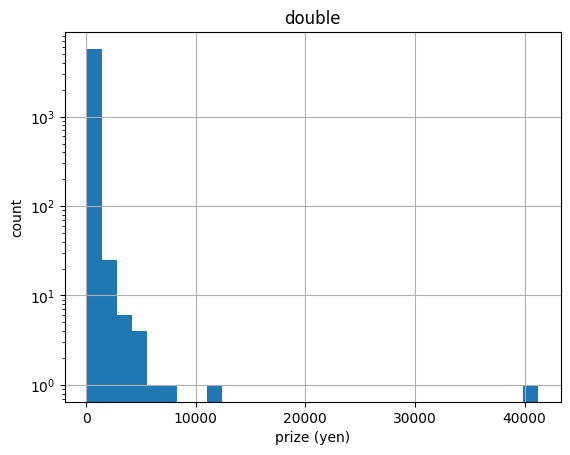

In [87]:
info(doub_prize, "double")

tri
最大  :  50170
平均  :  969


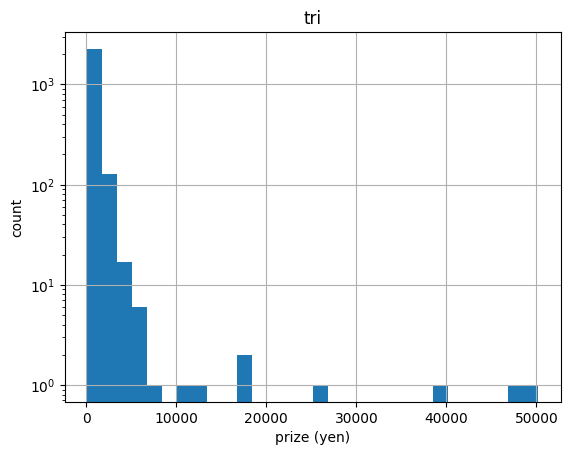

In [88]:
info(tri_prize, "tri")

trio
最大  :  19200
平均  :  359


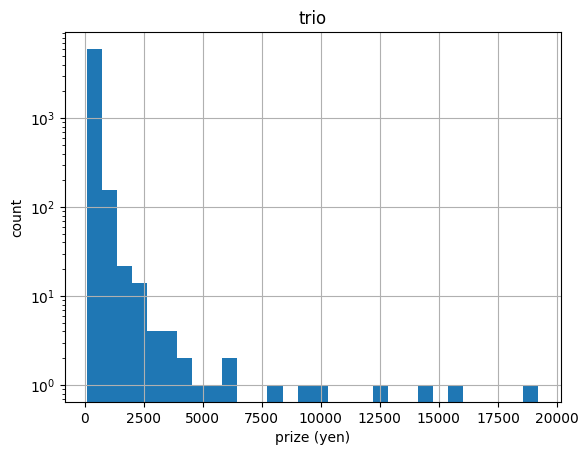

In [89]:
info(trio_prize, "trio")